In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from keras.applications import VGG16
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder


## Cargar los datos y primer modelo


In [2]:
def path_builder(path):
    built_path=os.path.sep.join(['.',path])
    return built_path

nimages_path=path_builder('imagenes/chest_xray/TFM/NORMAL')
pimages_path=path_builder('imagenes/chest_xray/TFM/PNEUMONIA')
nmimages_path=path_builder('imagenes/chest_xray/Muestra/Normal')
pmimages_path=path_builder('imagenes/chest_xray/Muestra/Pneumonia')

In [3]:
def rotate_images(image,label):
    image9 = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    image18 = cv2.rotate(image, cv2.ROTATE_180)
    image27 = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    images = np.array([image,image9,image18,image27])
    labels = [label,label,label,label]
    return images, labels

In [3]:
targets = []
images = []
def read_images(path,image_list,label_list,label):
    for image in os.listdir(path):
        image = os.path.sep.join([path, image])
    
        if os.path.exists(image):
            image = cv2.imread(image)            
            image = cv2.resize(image, (255, 255))
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)            
            image = image/255.0
            image = np.expand_dims(image, -1)
            images, labels = rotate_images(image,label)            
            image_list.extend(images)
            label_list.extend(labels)            
                       
        else:
            continue

read_images(nimages_path,images,targets,'Normal')
read_images(pimages_path,images,targets,'Pneumonia')
targets=np.asarray(targets)
images=np.asarray(images)


In [4]:
targets= targets.reshape(-1,1)
Encoder = OneHotEncoder(drop=['Normal'],handle_unknown='ignore',sparse_output=False)
targets = Encoder.fit_transform(targets)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(images, targets, test_size=0.2, random_state=5)

In [7]:
def prepare_dataset(x, sigma=0.2):
    x_noisy = x + sigma * tf.random.normal(shape=x.shape)
    x_noisy = tf.clip_by_value(x_noisy, clip_value_min=0., clip_value_max=1.)
    x_noisy = x_noisy.numpy()
    return (x_noisy)

x_train_noisy=prepare_dataset(x_train)
x_test_noisy=prepare_dataset(x_test)

In [4]:
# targets = []
# images = []
# for (id, row) in df.iterrows():
#    label = row["finding"]
#    imagepath = os.path.sep.join([images_path, row["filename"]])
#
#    if os.path.exists(imagepath):
#        image = cv2.imread(imagepath)
#        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
#        image = image/255.0
#        image = cv2.resize(image, (255, 255))
#        images.append(image)
#        targets.append(label)
#        
#    else:
#        continue

# images=np.asarray(images)
# targets=np.asarray(targets) 
    

In [17]:
inputs = tf.keras.Input(shape=(255, 255, 1), name='input')

# Conv Layer 1
conv_1 = layers.Conv2D(10, 4, padding='valid', activation='relu',
                       name='conv_1')(inputs)
pool_1 = layers.MaxPooling2D(pool_size=(2, 2), name='pool_1')(conv_1)
pool_1 = layers.Dropout(0.5,seed=30)(pool_1)

# Conv Layer 2
conv_2 = layers.Conv2D(10, 4, padding='valid', activation='relu',
                       name='conv_2')(pool_1)
pool_2 = layers.MaxPooling2D(pool_size=(2, 2), name='pool_2')(conv_2)
pool_2 = layers.Dropout(0.5,seed=30)(pool_2)


# Fully-connected
# Flattening
flat = layers.Flatten(name='flatten')(pool_2)
dense = layers.Dense(64, activation='relu', name='dense')(flat)
outputs = layers.Dense(1, activation='sigmoid', name='output')(dense)

model = keras.Model(inputs=inputs, outputs=outputs, name='first_model')

In [8]:
model.summary()

Model: "first_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 255, 255, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 252, 252, 10)   │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 123, 123, 10)   │         1,610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37210)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,381,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,349 (9.09 MB)

 Trainable params: 2,383,349 (9.09 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
es_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # can be 'val_accuracy'
    patience=5,  # if during 5 epochs there is no improvement in `val_loss`, the execution will stop
    verbose=1)

mc_callback = keras.callbacks.ModelCheckpoint(
    'best_model.keras', 
    monitor='val_loss', 
    save_best_only=True)

epochs = 10
model_results=model.fit(x=x_train, 
                        y=y_train, 
                        batch_size=16, 
                        epochs=epochs, 
                        validation_split=0.2,
                        callbacks=[es_callback, mc_callback])

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 55s 200ms/step - accuracy: 0.5846 - loss: 0.7467 - val_accuracy: 0.8771 - val_loss: 0.3722
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.8635 - loss: 0.3101 - val_accuracy: 0.9375 - val_loss: 0.1726
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 33s 140ms/step - accuracy: 0.9314 - loss: 0.1916 - val_accuracy: 0.9460 - val_loss: 0.1702
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.9334 - loss: 0.1687 - val_accuracy: 0.9523 - val_loss: 0.1302
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 137ms/step - accuracy: 0.9424 - loss: 0.1373 - val_accuracy: 0.9492 - val_loss: 0.1461
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 130ms/step - accuracy: 0.9489 - loss: 0.1328 - val_accuracy: 0.9523 - val_loss: 0.1434
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - accuracy: 0.9571 - loss: 0.1082 - val_accuracy: 0.9576 - val_loss: 0.1134
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 130ms/step - accuracy: 0.9567 - loss: 0

In [16]:
def show_loss_accuracy_evolution(history):

    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Crossentropy')
    ax1.plot(hist['epoch'], hist['loss'], label='Train Error')
    ax1.plot(hist['epoch'], hist['val_loss'], label = 'Val Error')
    ax1.grid()
    ax1.legend()

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    ax2.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()


In [ ]:
show_loss_accuracy_evolution(model_results)

In [21]:
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
predictions = model.predict(x_test)
y_predics = (predictions > 0.5).astype('int32')

print(f'Test accuracy: {accuracy*100:.2f}%')
print(confusion_matrix(y_test, y_predics))
print(classification_report(y_test, y_predics))

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
[[374  15]
 [ 25 530]]
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       389
         1.0       0.97      0.95      0.96       555

    accuracy                           0.96       944
   macro avg       0.95      0.96      0.96       944
weighted avg       0.96      0.96      0.96       944



In [83]:
def graficar_imagen(i, arr_predicciones, imagenes):
    prediccion = arr_predicciones[i][0]  # Asegurarse de tomar el primer valor si es un array
    img = imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img)
    
'''  porcentaje_pneumonia = prediccion * 100
    porcentaje_normal = (1 - prediccion) * 100

    plt.xlabel(f"Pneumonia: {porcentaje_pneumonia:.2f}%\nNormal: {porcentaje_normal:.2f}%")'''

'  porcentaje_pneumonia = prediccion * 100\n    porcentaje_normal = (1 - prediccion) * 100\n\n    plt.xlabel(f"Pneumonia: {porcentaje_pneumonia:.2f}%\nNormal: {porcentaje_normal:.2f}%")'

In [84]:
def graficar_valor_arreglo(i, arr_predicciones):
    prediccion = arr_predicciones[i][0]  # Asegurarse de tomar el primer valor si es un array
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar([0, 1], [1 - prediccion, prediccion], color=["red", "blue"])
    plt.ylim([0, 1])

    # Etiquetas para las barras
    plt.xticks([0, 1], ['Normal', 'Pneumonia'])
    for bar, percentage in zip(grafica, [1 - prediccion, prediccion]):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{percentage*100:.2f}%', va='bottom') 

In [24]:
filas = 5
columnas = 5
num_imagenes = filas * columnas

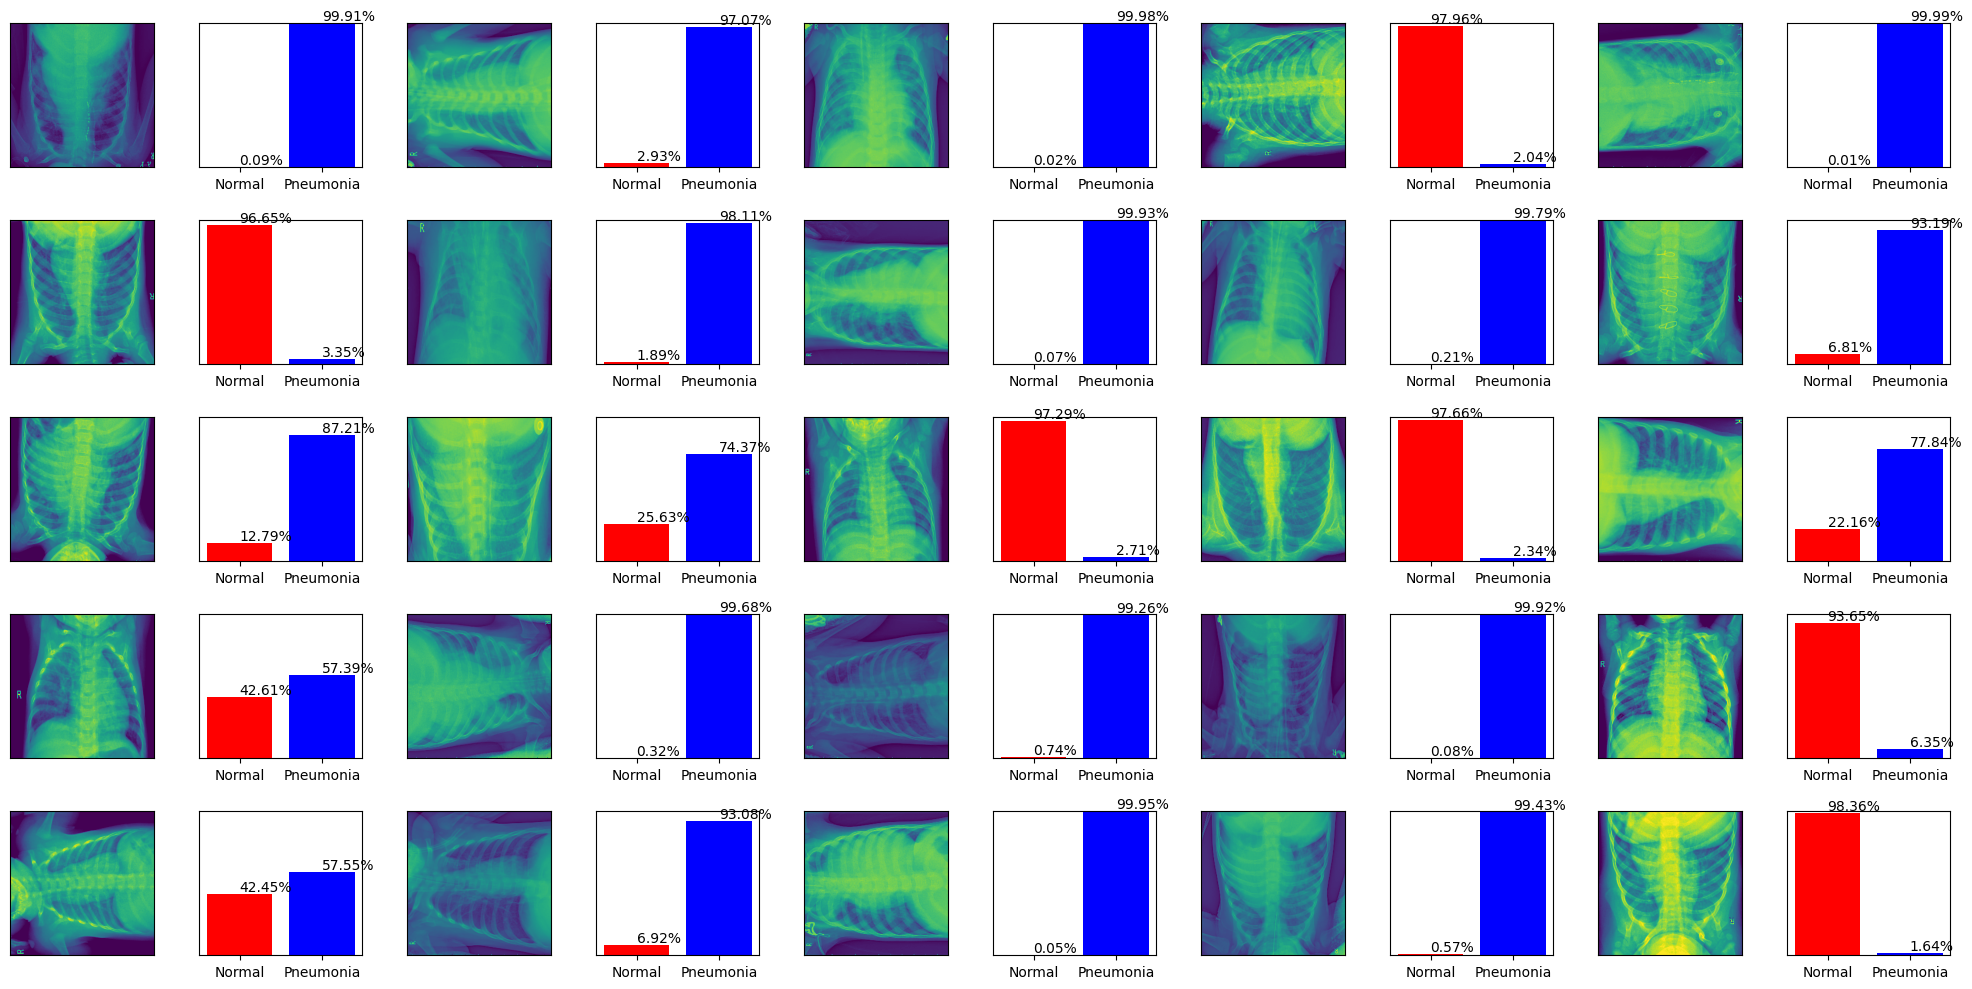

In [25]:
plt.figure(figsize=(2 * 2 * columnas, 2 * filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2 * columnas, 2 * i + 1)
    graficar_imagen(i, predictions, x_test)
    plt.subplot(filas, 2 * columnas, 2 * i + 2)
    graficar_valor_arreglo(i, predictions)

plt.tight_layout()
plt.show()

In [26]:
fpr, tpr, umbrales = metrics.roc_curve(y_test,y_predics)
# tn, fp, fn, tp = matrix.ravel()
# tpr = tp / (tp + fn)
# fpr = fp / (fp + tn)
roc = metrics.roc_auc_score(y_test,y_predics)


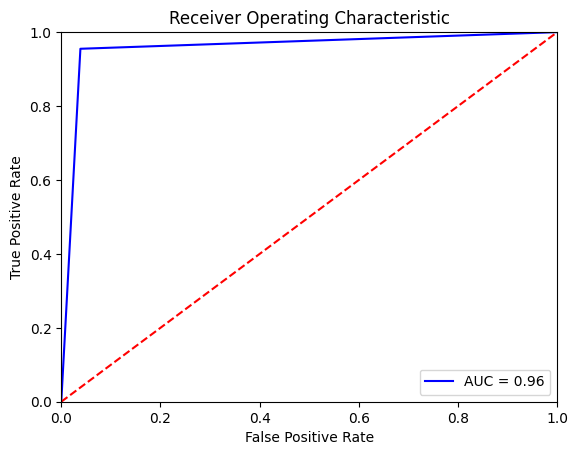

In [27]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Lectura de imágenes con Autoencoder para reducción de dimensionalidad y modelado

In [3]:
class Encoder(layers.Layer):
    def __init__(self, latent_dim, input_shape, name="encoder", **kwargs):
        super(Encoder, self).__init__(name=name, **kwargs)
        self.input_shape = input_shape
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([
            tf.keras.Input(shape=input_shape, name='input'),
            layers.Flatten(),
            layers.Dense(4*self.latent_dim, activation='relu'),
            layers.Dense(2*self.latent_dim, activation='relu'),
            layers.Dense(self.latent_dim, activation='relu')])                          
           
    def call(self, inputs):        
        x = self.encoder(inputs)                                    
        return x
    
    def get_config(self):
        config = super(Encoder, self).get_config()
        config.update({
            "latent_dim": self.latent_dim,
            "input_shape": self.input_shape,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


class Decoder(layers.Layer):
    """Converts z, the encoded digit vector, back into a readable digit."""

    def __init__(self, original_dim, latent_dim, name="decoder", **kwargs):
        super(Decoder, self).__init__(name=name, **kwargs)
        self.original_dim = original_dim
        self.latent_dim = latent_dim
        self.decoder = tf.keras.Sequential([
            layers.Dense(2*latent_dim, activation='relu'),
            layers.Dense(4*latent_dim, activation='relu'),
            layers.Dense(self.original_dim, activation='sigmoid'),
            layers.Reshape((1000,1000))])
                          
    def call(self, inputs):
        x = self.decoder(inputs)
        return x
    
    def get_config(self):
        config = super(Decoder, self).get_config()
        config.update({
            "original_dim":self.original_dim,
            "latent_dim":self.latent_dim,
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        return cls(**config)
    

class AutoEncoder2(tf.keras.Model):
    """Combines the encoder and decoder into an end-to-end model for training."""

    def __init__(
        self,
        original_dim,
        latent_dim,
        input_shape,
        name="autoencoder",
        **kwargs
    ):
        super(AutoEncoder2, self).__init__(name=name, **kwargs)
        self.latent_dim = latent_dim
        self.original_dim = original_dim
        self.input_shape = input_shape
        self.encoder = Encoder(latent_dim=latent_dim,input_shape=input_shape)
        self.decoder = Decoder(original_dim=original_dim,latent_dim=latent_dim)

    def call(self, inputs):
        x = self.encoder(inputs)
        x = self.decoder(x)
        return x
    
    def get_config(self):
        config = super(AutoEncoder2, self).get_config()
        config.update({
            "original_dim": self.original_dim,
            "latent_dim": self.latent_dim,
            "input_shape": self.input_shape,
        })
        return config
    
    @classmethod
    def from_config(cls,config):
        return cls(**config)

latent_dim= 64
original_dim=(1000*1000)
input_shape=(1000,1000)
autoencoder = AutoEncoder2(original_dim=original_dim, latent_dim=latent_dim, input_shape=input_shape)
autoencoder.compile(optimizer='adam', loss='mse')

In [6]:
muestra=[]
def read_muestra(path,image_list):
    for image in os.listdir(path):
        image = os.path.sep.join([path, image])

        if os.path.exists(image):
            image = cv2.imread(image)
            image = cv2.resize(image, (1000, 1000))            
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)            
            image = image/255.0            
            image_list.append(image)                                   
        else:
            continue
    
read_muestra(nmimages_path,muestra)
read_muestra(pmimages_path,muestra)
muestra=np.array(muestra)
# muestra=np.expand_dims(muestra,-1)  

In [5]:
autoencoder.fit(muestra,muestra,
                epochs=1,
                batch_size=10,
                validation_split=0.2)    

8/8 ━━━━━━━━━━━━━━━━━━━━ 165s 17s/step - loss: 0.0476 - val_loss: 0.0384


In [6]:
autoencoder.export('compresor')

INFO:tensorflow:Assets written to: compresor\assets


INFO:tensorflow:Assets written to: compresor\assets


Saved artifact at 'compresor'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1000, 1000), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1000, 1000), dtype=tf.float32, name=None)
Captures:
  1823083141200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1821675790864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1821675791440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1821675791632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1821675791248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1821675789904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1822902851856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1822902850704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1822902851280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1822902851664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1822902848592: TensorSpec(shape=(), dtype=t

In [3]:
autoencoder = tf.saved_model.load('compresor')

In [6]:
autoencoder = keras.models.load_model('compresor.keras', custom_objects={'Encoder': Encoder, 'Decoder': Decoder, 'AutoEncoder2': AutoEncoder2})

TypeError: Could not locate class 'AutoEncoder2'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'AutoEncoder2', 'config': {'name': 'autoencoder', 'trainable': True, 'dtype': 'float32'}, 'registered_name': 'AutoEncoder2', 'build_config': {'input_shape': [10, 1000, 1000]}, 'compile_config': {'optimizer': 'adam', 'loss': 'mse', 'loss_weights': None, 'metrics': None, 'weighted_metrics': None, 'run_eagerly': False, 'steps_per_execution': 1, 'jit_compile': False}}

In [8]:
test_mse = autoencoder.evaluate(muestra, muestra)
print('MSE Test:', test_mse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 418ms/step - loss: 0.0298
MSE Test: 0.029310351237654686


In [10]:
images=[]
targets=[]
def reconstruct_images(path,image_list,label_list,label):
    for image in os.listdir(path):
        image = os.path.sep.join([path, image])
    
        if os.path.exists(image):
            image = cv2.imread(image)            
            image = cv2.resize(image, (1000, 1000))
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)            
            image = image/255.0
            images, labels = rotate_images(image,label)            
            images = autoencoder.encoder(images).numpy()
            images = images.tolist()            
            image_list.extend(images)
            label_list.extend(labels)
                                   
        else:
            continue

reconstruct_images(nimages_path,images,targets,'Normal')
reconstruct_images(pimages_path,images,targets,'Pneumonia')
targets=np.asarray(targets)
images=np.asarray(images)

In [13]:
targets= targets.reshape(-1,1)
Encoder = OneHotEncoder(drop=['Normal'],handle_unknown='ignore',sparse_output=False)
targets = Encoder.fit_transform(targets)

# Encontrar valores constantes en imágenes comprimidas y descartarlos

In [5]:
targets=np.load('targets.npy')
images=np.load('imagenes.npy')
images_df=pd.DataFrame(images)
images_df["Target"]=targets

In [6]:
def calculate_woe_ivs(df,variable,target,bins=10):
   
   df_woe=pd.DataFrame()

   if df[variable].nunique() > bins:
      cat_variable = pd.qcut(df[variable],bins,duplicates='drop')
      df_cat = pd.DataFrame({'cats':cat_variable,'Y':df[target]})
   else:
      df_cat = pd.DataFrame({'cats':df[variable],'Y':df[target]})

   df_woe=pd.concat([df_woe,df_cat['cats'].astype('category'),df_cat['Y']],axis=1)
   df_woe=df_woe.groupby(by=['cats'],observed=True)[['Y']].agg(['count','sum'])
   df_woe.columns = ['Total', 'Bad']
   df_woe['Good'] = df_woe['Total'] - df_woe['Bad']
   df_woe['Good_porc']=df_woe['Good']/df_woe['Good'].sum()
   df_woe['Bad_porc']=df_woe['Bad']/df_woe['Bad'].sum()
   df_woe['WoE']=np.log(df_woe['Good_porc']/df_woe['Bad_porc'])
   df_woe['IV']=df_woe['WoE']*(df_woe['Bad_porc']-df_woe['Good_porc'])      
   woe = df_woe['WoE'].sum()
   iv = df_woe['IV'].sum()

   if (woe < 0) & (iv < 0):
      woe = -woe
      iv = -iv
   elif woe < 0:
      woe = -woe
   elif iv < 0:
      iv = -iv

   df_ivs = pd.DataFrame([[variable, woe, iv]],columns=['Variable','WoE','IV'])
   return df_ivs

In [7]:
df_ivs=pd.DataFrame()
features=images_df.iloc[:,0:64]

for feature in features:
    df_iv=calculate_woe_ivs(images_df,feature,'Target')
    df_ivs=pd.concat([df_ivs,df_iv],axis=0)


d:\Python\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
drop_vars = []
for (i, row) in df_ivs.iterrows():
    if (row["IV"] < 0.1) or (np.isinf(row["IV"])):
        drop_vars.append(row["Variable"])        

In [9]:
images_red=images_df.drop(columns=drop_vars)

In [10]:
validation = images_red.sample(n=100, random_state=5)
images_red = images_red.drop(validation.index)

In [11]:
targets = images_red['Target']
images_red = images_red.drop(columns=['Target'])
targets.shape

(23260,)

# PCA

In [12]:
pca = PCA(n_components=4)
pca_results = pca.fit_transform(images_red)
pca_df = pd.DataFrame(data=pca_results, columns = ['PC1', 'PC2','PC3','PC4'])

In [13]:
print(pca_df.head())
print(f"\nVariance explained: {np.round(pca.explained_variance_ratio_, 2)}")

         PC1       PC2       PC3       PC4
0   9.616955  2.041202 -0.707535  0.640489
1   5.322898 -1.948563 -0.226819  0.110856
2   5.898630  0.263511 -0.854678  0.238491
3   4.363696 -0.863595 -0.866882 -0.079131
4  18.004988  4.471616  0.399627  0.098597

Variance explained: [0.95 0.05 0.   0.  ]


In [14]:
pca_df = pca_df.drop(columns=['PC3','PC4'])

# Modelos

## Red neuronal

In [88]:
x_train, x_test, y_train, y_test = train_test_split(pca_df, targets, test_size=0.2, random_state=5)

In [89]:
inputs = keras.Input(shape=(2,), name='input_layer')

l_1 = layers.Dense(2, activation='relu')(inputs)
# l_1 = layers.Dropout(0.5,seed=30, name='dropout_l1')(l_1)
l_2 = layers.Dense(4, activation='relu')(l_1)
# l_2 = layers.Dropout(0.5,seed=30, name='dropout_l2')(l_2)
l_3 = layers.Dense(4, activation='relu')(l_2)
# l_3 = layers.Dropout(0.5,seed=30, name='dropout_l3')(l_3)
l_4 = layers.Dense(2, activation='relu')(l_3)
# l_4 = layers.Dropout(0.5,seed=30, name='dropout_l4')(l_4)
# l_5 = layers.Dense(10, activation='relu')(l_4)
# l_5 = layers.Dropout(0.5,seed=30, name='dropout_l5')(l_5)

outputs = layers.Dense(1, activation='sigmoid', name='output')(l_4)

model2 = keras.Model(inputs=inputs, outputs=outputs, name='second_model')

In [90]:
model2.summary()

Model: "second_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [91]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [92]:
es_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # can be 'val_accuracy'
    patience=5,  # if during 5 epochs there is no improvement in `val_loss`, the execution will stop
    verbose=1)

epochs = 10
model2_results=model2.fit(x=x_train, 
                        y=y_train, 
                        batch_size=16, 
                        epochs=epochs, 
                        validation_split=0.1,
                        callbacks=[es_callback])

Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7300 - loss: 0.6532 - val_accuracy: 0.7281 - val_loss: 0.5949
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7270 - loss: 0.5916 - val_accuracy: 0.7281 - val_loss: 0.5853
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7346 - loss: 0.5790 - val_accuracy: 0.7281 - val_loss: 0.5851
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7339 - loss: 0.5794 - val_accuracy: 0.7281 - val_loss: 0.5852
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7329 - loss: 0.5804 - val_accuracy: 0.7281 - val_loss: 0.5852
Epoch 6/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7339 - loss: 0.5794 - val_accuracy: 0.7281 - val_loss: 0.5852
Epoch 7/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7309 - loss: 0.5824 - val_accuracy: 0.7281 - val_loss: 0.5852
Epoch 8/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7315 - loss: 0.5818 - 

In [70]:
show_loss_accuracy_evolution(model2_results)

NameError: name 'show_loss_accuracy_evolution' is not defined

In [152]:
model2.save('model2-10red_1.keras')

In [3]:
model2 = keras.models.load_model('model2-10red.keras', custom_objects={'Adam': tf.keras.optimizers.Adam})

In [196]:
predictions = model2.predict(x_test)
y_predics = (predictions > 0.73).astype('int32')


print(confusion_matrix(y_test, y_predics))
print(classification_report(y_test, y_predics))

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1291    0]
 [   0 3381]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1291
         1.0       1.00      1.00      1.00      3381

    accuracy                           1.00      4672
   macro avg       1.00      1.00      1.00      4672
weighted avg       1.00      1.00      1.00      4672



In [197]:
fpr, tpr, umbrales = metrics.roc_curve(y_test,y_predics)
# tn, fp, fn, tp = matrix.ravel()
# tpr = tp / (tp + fn)
# fpr = fp / (fp + tn)
roc = metrics.roc_auc_score(y_test,y_predics)


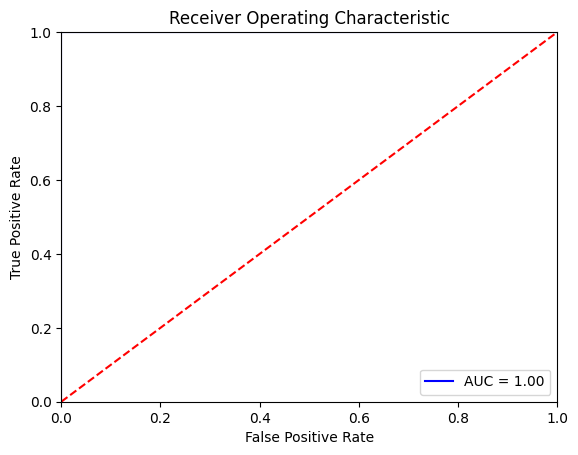

In [198]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Otro clasificador

In [15]:
targets=targets.ravel()
x_train, x_test, y_train, y_test = train_test_split(images_red, targets, test_size=0.2, random_state=5)

In [19]:
param_grid = {'n_estimators': [50,75,100,150],
              'max_features': [3, 6, 9],
              'max_depth'   : [None, 3,9,10,20]
             }

# Búsqueda por grid search con validación cruzada
grid = GridSearchCV(
        estimator  = RandomForestClassifier(random_state = 123),
        param_grid = param_grid,
        scoring    = 'accuracy',
        n_jobs     = -1,
        cv         = RepeatedKFold(n_splits=10, n_repeats=3, random_state=123), 
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid.fit(X = x_train, y = y_train)

# Resultados
print(grid.best_estimator_)

RandomForestClassifier(max_features=9, n_estimators=150, random_state=123)


In [124]:
param_grid = {'max_depth':[4,5,10,20], 'min_samples_leaf': [2,3,4,5,10], 'min_samples_split': [4,5,6,7,8,9,10]}
grid = GridSearchCV(DecisionTreeClassifier(random_state = 125), 
                     param_grid, 
                     cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=123),
                     scoring='accuracy', 
                     n_jobs=-1,
                     refit=True,
                     verbose=0,
                     return_train_score=True)
grid.fit(X = x_train, y = y_train)

print(grid.best_estimator_)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=4,
                       random_state=125)


In [16]:
DT = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=4, random_state=125)
DT.fit(x_train, y_train)
acierto_entrenamiento = DT.score(x_train, y_train)
acierto_test = DT.score(x_test, y_test)
print("Acierto en el conjunto de entrenamiento: {0:.2f}%".format(acierto_entrenamiento*100.))
print("Acierto en el conjunto de test: {0:.2f}%".format(acierto_test*100.))

Acierto en el conjunto de entrenamiento: 75.64%
Acierto en el conjunto de test: 72.06%


In [20]:
RF = RandomForestClassifier(max_features=9, n_estimators=150, random_state=123)
RF.fit(x_train, y_train)
acierto_entrenamiento = RF.score(x_train, y_train)
acierto_test = RF.score(x_test, y_test)
print("Acierto en el conjunto de entrenamiento: {0:.2f}%".format(acierto_entrenamiento*100.))
print("Acierto en el conjunto de test: {0:.2f}%".format(acierto_test*100.))

Acierto en el conjunto de entrenamiento: 100.00%
Acierto en el conjunto de test: 76.72%


In [22]:
predictions = RF.predict(x_test)
y_predics = (predictions > 0.5).astype('int32')


print(confusion_matrix(y_test, y_predics))
print(classification_report(y_test, y_predics))

[[ 481  799]
 [ 284 3088]]
              precision    recall  f1-score   support

         0.0       0.63      0.38      0.47      1280
         1.0       0.79      0.92      0.85      3372

    accuracy                           0.77      4652
   macro avg       0.71      0.65      0.66      4652
weighted avg       0.75      0.77      0.75      4652



In [13]:
fpr, tpr, umbrales = metrics.roc_curve(y_test,y_predics)
# tn, fp, fn, tp = matrix.ravel()
# tpr = tp / (tp + fn)
# fpr = fp / (fp + tn)
roc = metrics.roc_auc_score(y_test,y_predics)


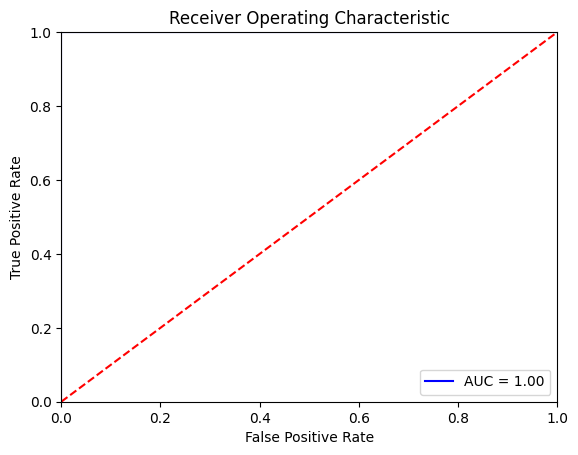

In [14]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Cargar imágenes con un modelo preentrenado cuyo output sera el input para nuestra red neuronal

In [3]:
def pretrain_model(model,shape):
    pretrained_model = model(include_top=False, input_tensor=shape, weights='imagenet')
    pretrained_model.trainable=False
    # pretrained_model = keras.Model(inputs=pretrained_model.input,outputs=pretrained_model.output)
    # model.compile(optimizer='adam')
    
    return pretrained_model


In [4]:
targets = []
images = []
def read_images(path,image_list,label_list,label):
    for image in os.listdir(path):
        image = os.path.sep.join([path, image])
    
        if os.path.exists(image):
            image = cv2.imread(image)            
            image = cv2.resize(image, (255, 255))           
            # images, labels = rotate_images(image,label)            
            # images = images.tolist()            
            # image_list.extend(images)
            # label_list.extend(labels)
            image_list.append(image)
            label_list.append(label)            
                       
        else:
            continue

read_images(nimages_path,images,targets,'Normal')
read_images(pimages_path,images,targets,'Pneumonia')
targets=np.asarray(targets)
images=np.asarray(images)

In [8]:
# images=[]
# targets=[]
# def vector_images(path,image_list,label_list,label):

    # for image in os.listdir(path):
        # image = os.path.sep.join([path, image])
    
        # if os.path.exists(image):
           # image = cv2.imread(image)             
           # image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)            
           # image = image/255.0
           # image = np.expand_dims(image, -1)            
           # model = pretrain_model(VGG16,image.shape)
           # image = model.predict(image)                  
           # image_list.append(image)
           # label_list.append(label)
                       
        # else:
            # continue

# vector_images(nimages_path,images,targets,'Normal')
# vector_images(pimages_path,images,targets,'Pneumonia')
# targets=np.asarray(targets)
# images=np.asarray(images)


(1317, 1857, 3)


ValueError: Input 0 of layer "functional_5" is incompatible with the layer: expected shape=(None, 1317, 1857, 3), found shape=(32, 1857, 3)

In [5]:
targets= targets.reshape(-1,1)
Encoder = OneHotEncoder(drop=['Normal'],handle_unknown='ignore',sparse_output=False)
targets = Encoder.fit_transform(targets)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(images, targets, test_size=0.2, random_state=5)

In [7]:
pretrained_model=pretrain_model(VGG16,tf.keras.Input(shape=(255,255,3)))
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 255, 255, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 255, 255, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 127, 127, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 127, 127, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 63, 63, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 63, 63, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 63, 63, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 63, 63, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 31, 31, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
inputs = tf.keras.Input(shape=(255,255,3), name='input')

x = pretrained_model(inputs)

flat = layers.Flatten(name='flatten')(x)
dense = layers.Dense(64, activation='relu', name='dense')(flat)
dense = layers.Dense(32, activation='relu', name='dense1')(dense)
drop = layers.Dropout(0.5,seed=30, name='dropout')(dense)
outputs = layers.Dense(1, activation='sigmoid', name='output')(drop)

model3 = keras.Model(inputs=inputs, outputs=outputs, name='Third_model')

In [9]:
model3.summary()

Model: "Third_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,322,497 (62.27 MB)

 Trainable params: 1,607,809 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
es_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # can be 'val_accuracy'
    patience=5,  # if during 5 epochs there is no improvement in `val_loss`, the execution will stop
    verbose=1)

epochs = 10
model_results3=model3.fit(x=x_train, 
                        y=y_train, 
                        batch_size=32, 
                        epochs=epochs, 
                        validation_split=0.2,
                        callbacks=[es_callback])

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 701s 5s/step - accuracy: 0.8104 - loss: 0.8806 - val_accuracy: 0.9359 - val_loss: 0.2085
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 665s 5s/step - accuracy: 0.9296 - loss: 0.2140 - val_accuracy: 0.9359 - val_loss: 0.2495
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 722s 5s/step - accuracy: 0.9604 - loss: 0.1138 - val_accuracy: 0.9338 - val_loss: 0.2326
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 724s 5s/step - accuracy: 0.9586 - loss: 0.1067 - val_accuracy: 0.9423 - val_loss: 0.2062
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 728s 6s/step - accuracy: 0.9740 - loss: 0.0615 - val_accuracy: 0.9423 - val_loss: 0.1961
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 727s 6s/step - accuracy: 0.9837 - loss: 0.0457 - val_accuracy: 0.9444 - val_loss: 0.2552
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 729s 6s/step - accuracy: 0.9894 - loss: 0.0355 - val_accuracy: 0.9380 - val_loss: 0.2399
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 734s 6s/step - accuracy: 0.9919 - loss: 0.0261 - val_accu

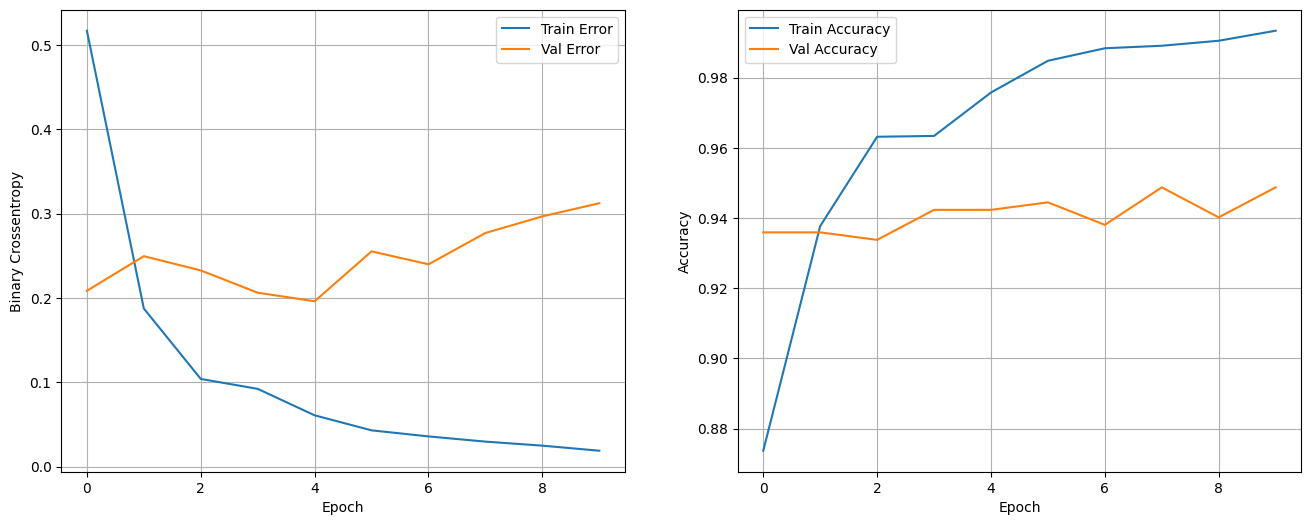

In [18]:
show_loss_accuracy_evolution(model_results3)

In [ ]:
predictions = model.predict(x_test)
y_predics = (predictions > 0.5).astype('int32')


print(confusion_matrix(y_test, y_predics))
print(classification_report(y_test, y_predics))

In [ ]:
filas = 5
columnas = 5
num_imagenes = filas * columnas

In [ ]:
plt.figure(figsize=(2 * 2 * columnas, 2 * filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2 * columnas, 2 * i + 1)
    graficar_imagen(i, predictions, x_test)
    plt.subplot(filas, 2 * columnas, 2 * i + 2)
    graficar_valor_arreglo(i, predictions)

plt.tight_layout()
plt.show()

In [ ]:
fpr, tpr, umbrales = metrics.roc_curve(y_test,y_predics)
# tn, fp, fn, tp = matrix.ravel()
# tpr = tp / (tp + fn)
# fpr = fp / (fp + tn)
roc = metrics.roc_auc_score(y_test,y_predics)

In [ ]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()